In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded!")

All libraries loaded!


In [5]:
df = pd.read_csv(r'C:\Users\Aviral Goel\wildfire_prediction\data\CA_Weather_Fire_Dataset_1984-2025 (1).csv')

print("Shape:", df.shape)
print("\nColumn names:")
for col in df.columns:
    print(" -", col)

Shape: (14988, 14)

Column names:
 - DATE
 - PRECIPITATION
 - MAX_TEMP
 - MIN_TEMP
 - AVG_WIND_SPEED
 - FIRE_START_DAY
 - YEAR
 - TEMP_RANGE
 - WIND_TEMP_RATIO
 - MONTH
 - SEASON
 - LAGGED_PRECIPITATION
 - LAGGED_AVG_WIND_SPEED
 - DAY_OF_YEAR


In [6]:
# See first 5 rows
df.head()

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1/1/1984,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1
1,1/2/1984,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2
2,1/3/1984,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3
3,1/4/1984,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4
4,1/5/1984,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5


In [7]:
# Check what FIRE_START_DAY looks like - this is our target column
print("Fire column values:")
print(df['FIRE_START_DAY'].value_counts())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Fire column values:
FIRE_START_DAY
False    10017
True      4971
Name: count, dtype: int64

Data types:
DATE                         str
PRECIPITATION            float64
MAX_TEMP                 float64
MIN_TEMP                 float64
AVG_WIND_SPEED           float64
FIRE_START_DAY              bool
YEAR                       int64
TEMP_RANGE               float64
WIND_TEMP_RATIO          float64
MONTH                      int64
SEASON                       str
LAGGED_PRECIPITATION     float64
LAGGED_AVG_WIND_SPEED    float64
DAY_OF_YEAR                int64
dtype: object

Missing values:
DATE                      0
PRECIPITATION             1
MAX_TEMP                  1
MIN_TEMP                  1
AVG_WIND_SPEED           12
FIRE_START_DAY            0
YEAR                      0
TEMP_RANGE                1
WIND_TEMP_RATIO          12
MONTH                     0
SEASON                    0
LAGGED_PRECIPITATION      0
LAGGED_AVG_WIND_SPEED     0
DAY_OF_YEAR               0
dtype: int6

In [8]:
# Convert target to 0/1 (easier for ML models)
df['FIRE_START_DAY'] = df['FIRE_START_DAY'].astype(int)

print("Target distribution:")
print(df['FIRE_START_DAY'].value_counts())
print(f"\nFire rate: {df['FIRE_START_DAY'].mean()*100:.1f}% of days had fire")

Target distribution:
FIRE_START_DAY
0    10017
1     4971
Name: count, dtype: int64

Fire rate: 33.2% of days had fire


In [9]:
# Convert SEASON text to numbers
season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
df['SEASON'] = df['SEASON'].map(season_map)

# Convert DATE to datetime and extract useful parts
df['DATE'] = pd.to_datetime(df['DATE'])
df['DAY'] = df['DATE'].dt.day

# Drop DATE column (can't feed raw dates to ML models)
df = df.drop(columns=['DATE'])

print("Done! New shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Done! New shape: (14988, 14)

First 3 rows:


,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,DAY
0,0.0,79.0,51.0,4.70,0,1984,28.0,0.059494,1,0,0.0,4.700,1,1
1,0.0,71.0,46.0,5.59,0,1984,25.0,0.078732,1,0,0.0,5.145,2,2
2,0.0,70.0,47.0,5.37,0,1984,23.0,0.076714,1,0,0.0,5.220,3,3


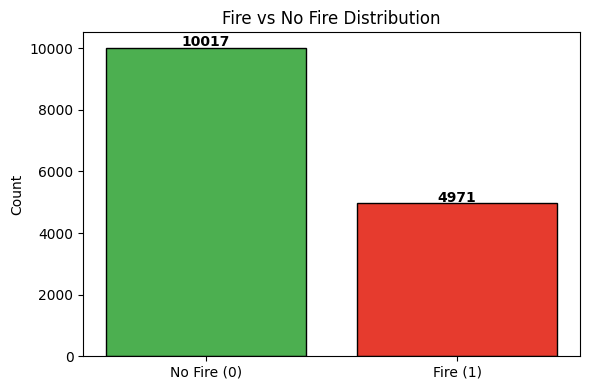

In [10]:
# Plot 1 - Fire vs No Fire count
plt.figure(figsize=(6,4))
bars = plt.bar(['No Fire (0)', 'Fire (1)'], 
               df['FIRE_START_DAY'].value_counts().sort_index(),
               color=['#4CAF50', '#E63B2E'], edgecolor='black')
plt.title('Fire vs No Fire Distribution')
plt.ylabel('Count')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/fire_distribution.png')
plt.show()

<Figure size 800x500 with 0 Axes>

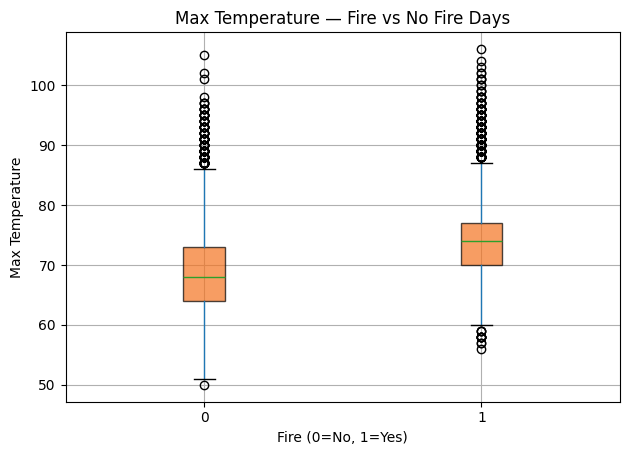

In [11]:
# Plot 2 - Temperature on fire days vs non-fire days
plt.figure(figsize=(8,5))
df.boxplot(column='MAX_TEMP', by='FIRE_START_DAY', 
           notch=False, patch_artist=True,
           boxprops=dict(facecolor='#F47421', alpha=0.7))
plt.title('Max Temperature — Fire vs No Fire Days')
plt.suptitle('')
plt.xlabel('Fire (0=No, 1=Yes)')
plt.ylabel('Max Temperature')
plt.tight_layout()
plt.savefig('../outputs/temp_vs_fire.png')
plt.show()

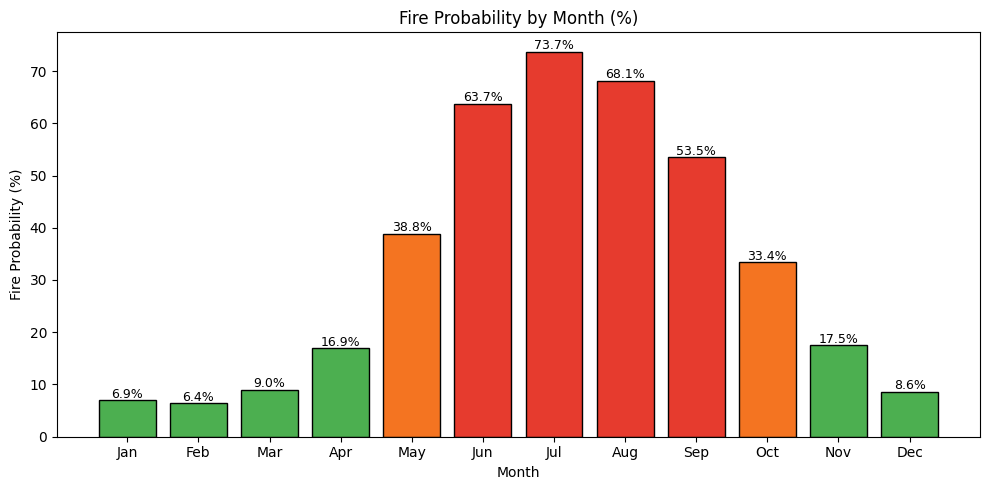

In [12]:
# Plot 3 - Monthly fire frequency
monthly = df.groupby('MONTH')['FIRE_START_DAY'].mean() * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,5))
colors = ['#E63B2E' if x > 40 else '#F47421' if x > 20 else '#4CAF50' 
          for x in monthly]
plt.bar(month_names, monthly, color=colors, edgecolor='black')
plt.title('Fire Probability by Month (%)')
plt.ylabel('Fire Probability (%)')
plt.xlabel('Month')
for i, v in enumerate(monthly):
    plt.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/monthly_fire.png')
plt.show()

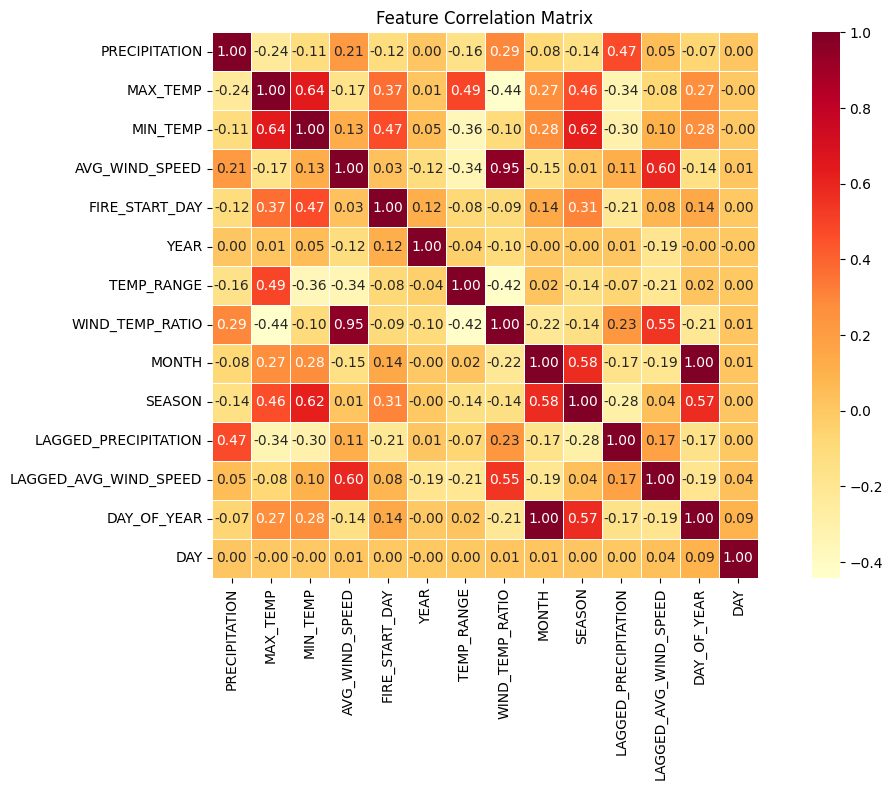

In [13]:
# Plot 4 - Correlation heatmap
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
mask = corr == 1.0
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()

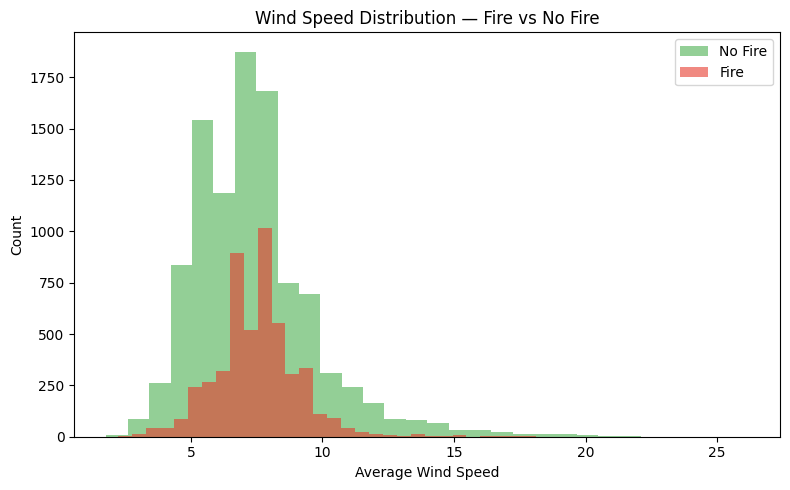

In [14]:
# Plot 5 - Wind Speed vs Fire
plt.figure(figsize=(8,5))
fire_wind = df[df['FIRE_START_DAY']==1]['AVG_WIND_SPEED']
nofire_wind = df[df['FIRE_START_DAY']==0]['AVG_WIND_SPEED']

plt.hist(nofire_wind, bins=30, alpha=0.6, color='#4CAF50', label='No Fire')
plt.hist(fire_wind, bins=30, alpha=0.6, color='#E63B2E', label='Fire')
plt.xlabel('Average Wind Speed')
plt.ylabel('Count')
plt.title('Wind Speed Distribution — Fire vs No Fire')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/wind_vs_fire.png')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
X = df.drop(columns=['FIRE_START_DAY'])
y = df['FIRE_START_DAY']

print("Features:", X.columns.tolist())
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Features: ['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 'YEAR', 'TEMP_RANGE', 'WIND_TEMP_RATIO', 'MONTH', 'SEASON', 'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED', 'DAY_OF_YEAR', 'DAY']
Feature shape: (14988, 13)
Target shape: (14988,)


In [16]:
# Split data - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% for testing
    random_state=42,     # so we get same split every time
    stratify=y           # keeps same fire ratio in both splits
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"\nFire cases in training : {y_train.sum()}")
print(f"Fire cases in testing  : {y_test.sum()}")

Training samples : 11990
Testing samples  : 2998

Fire cases in training : 3977
Fire cases in testing  : 994


In [17]:
# Scale the features
# This makes all numbers on same scale - important for good model performance
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on training
X_test_scaled = scaler.transform(X_test)          # ONLY transform on testing (never fit)

print("Scaling done!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

Scaling done!
Training data shape: (11990, 13)
Testing data shape : (2998, 13)


In [18]:
import joblib
import os

# Save scaler so we can use it later for predictions
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')

print("Scaler saved!")

Scaler saved!


In [19]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest... please wait")

rf_model = RandomForestClassifier(
    n_estimators=200,      # 200 decision trees
    max_depth=12,          # how deep each tree can grow
    min_samples_split=5,   # minimum samples needed to split a node
    min_samples_leaf=2,    # minimum samples at each leaf
    random_state=42,       # for reproducibility
    n_jobs=-1              # use all CPU cores to speed up
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest training DONE!")

Training Random Forest... please wait
Random Forest training DONE!


In [20]:
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             roc_auc_score, confusion_matrix,
                             classification_report)

# Make predictions
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate all metrics
print("="*40)
print("   RANDOM FOREST RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, rf_pred):.4f}")
print(f"Recall    : {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, rf_prob):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, rf_pred, 
      target_names=['No Fire', 'Fire']))

   RANDOM FOREST RESULTS
Accuracy  : 79.32%
Precision : 0.7033
Recall    : 0.6509
F1 Score  : 0.6761
ROC-AUC   : 0.8567

Detailed Report:
              precision    recall  f1-score   support

     No Fire       0.83      0.86      0.85      2004
        Fire       0.70      0.65      0.68       994

    accuracy                           0.79      2998
   macro avg       0.77      0.76      0.76      2998
weighted avg       0.79      0.79      0.79      2998



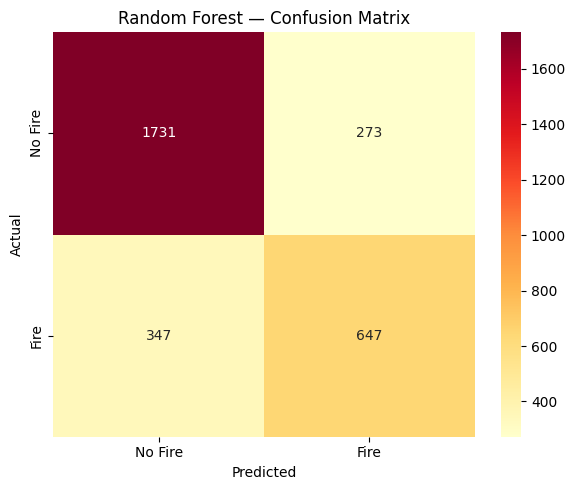


True Negatives  (correctly said No Fire): 1731
False Positives (said Fire but was No Fire): 273
False Negatives (said No Fire but was Fire): 347
True Positives  (correctly said Fire): 647


In [21]:
# Confusion Matrix for Random Forest
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['No Fire', 'Fire'],
            yticklabels=['No Fire', 'Fire'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/rf_confusion_matrix.png')
plt.show()

print(f"\nTrue Negatives  (correctly said No Fire): {cm[0][0]}")
print(f"False Positives (said Fire but was No Fire): {cm[0][1]}")
print(f"False Negatives (said No Fire but was Fire): {cm[1][0]}")
print(f"True Positives  (correctly said Fire): {cm[1][1]}")

In [22]:
# Save Random Forest model
joblib.dump(rf_model, '../models/random_forest_model.pkl')
print("Random Forest model saved!")

Random Forest model saved!


In [23]:
from xgboost import XGBClassifier

print("Training XGBoost... please wait")

xgb_model = XGBClassifier(
    n_estimators=300,        # 300 trees
    max_depth=6,             # depth of each tree
    learning_rate=0.05,      # how fast it learns (slower = better)
    subsample=0.8,           # use 80% of data per tree
    colsample_bytree=0.8,    # use 80% of features per tree
    random_state=42,
    eval_metric='logloss',   # how it measures error during training
    verbosity=0              # don't print training logs
)

xgb_model.fit(X_train_scaled, y_train)

print("XGBoost training DONE!")

Training XGBoost... please wait
XGBoost training DONE!


In [24]:
# Make predictions
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("="*40)
print("   XGBOOST RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall    : {recall_score(y_test, xgb_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, xgb_prob):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['No Fire', 'Fire']))

   XGBOOST RESULTS
Accuracy  : 79.95%
Precision : 0.7071
Recall    : 0.6751
F1 Score  : 0.6907
ROC-AUC   : 0.8634

Detailed Report:
              precision    recall  f1-score   support

     No Fire       0.84      0.86      0.85      2004
        Fire       0.71      0.68      0.69       994

    accuracy                           0.80      2998
   macro avg       0.77      0.77      0.77      2998
weighted avg       0.80      0.80      0.80      2998



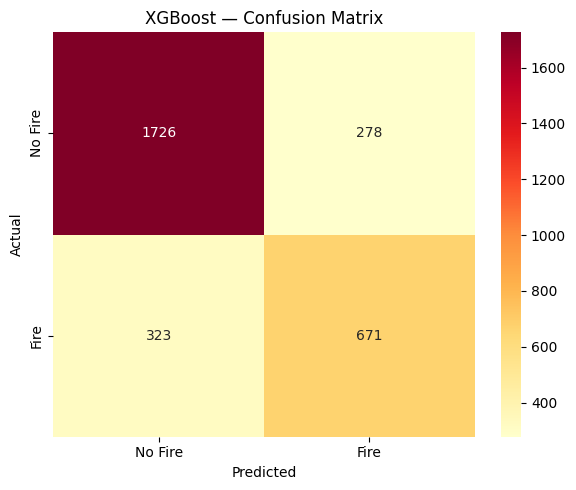

In [25]:
# Confusion Matrix for XGBoost
plt.figure(figsize=(6,5))
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['No Fire', 'Fire'],
            yticklabels=['No Fire', 'Fire'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/xgb_confusion_matrix.png')
plt.show()

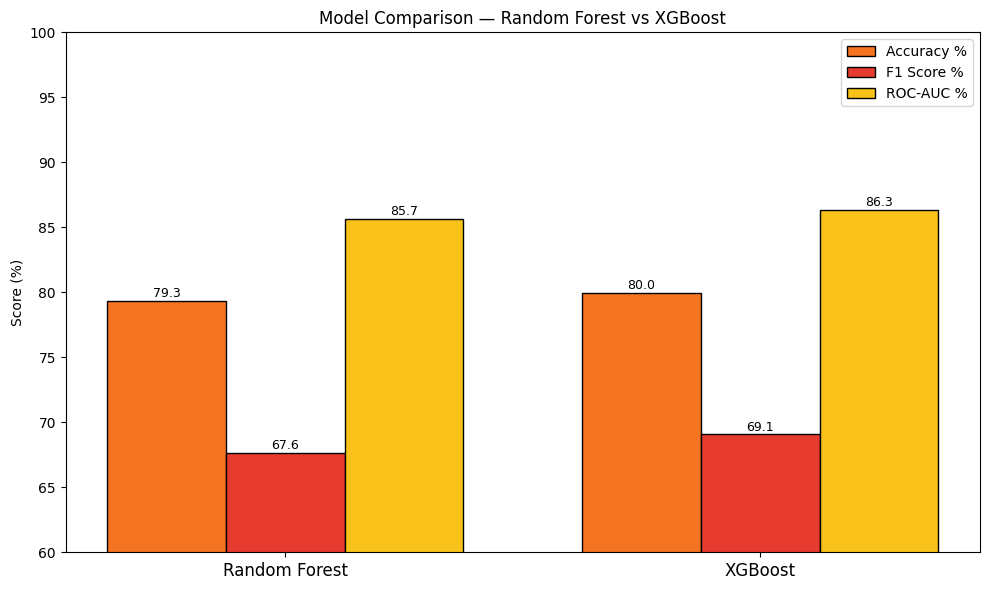

In [26]:
# Compare both models side by side
models = ['Random Forest', 'XGBoost']
accuracy  = [accuracy_score(y_test, rf_pred)*100, 
             accuracy_score(y_test, xgb_pred)*100]
f1        = [f1_score(y_test, rf_pred), 
             f1_score(y_test, xgb_pred)]
roc_auc   = [roc_auc_score(y_test, rf_prob), 
             roc_auc_score(y_test, xgb_prob)]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
bars1 = plt.bar(x - width, accuracy, width, label='Accuracy %', 
                color='#F47421', edgecolor='black')
bars2 = plt.bar(x,          [f*100 for f in f1], width, label='F1 Score %', 
                color='#E63B2E', edgecolor='black')
bars3 = plt.bar(x + width,  [r*100 for r in roc_auc], width, label='ROC-AUC %', 
                color='#F9C21A', edgecolor='black')

plt.ylabel('Score (%)')
plt.title('Model Comparison — Random Forest vs XGBoost')
plt.xticks(x, models, fontsize=12)
plt.ylim(60, 100)
plt.legend()

for bar in [*bars1, *bars2, *bars3]:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

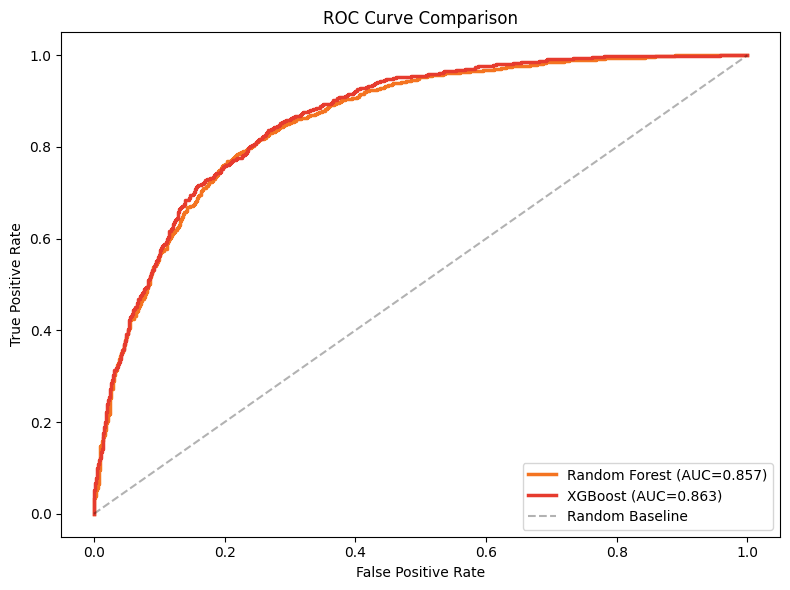

In [27]:
# ROC Curve for both models
from sklearn.metrics import roc_curve

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf,  tpr_rf,  
         label=f'Random Forest (AUC={roc_auc_score(y_test,rf_prob):.3f})',
         color='#F47421', linewidth=2.5)
plt.plot(fpr_xgb, tpr_xgb, 
         label=f'XGBoost (AUC={roc_auc_score(y_test,xgb_prob):.3f})',
         color='#E63B2E', linewidth=2.5)
plt.plot([0,1],[0,1], 'k--', alpha=0.3, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_comparison.png')
plt.show()

In [28]:
# Save XGBoost model
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
print("XGBoost model saved!")

XGBoost model saved!


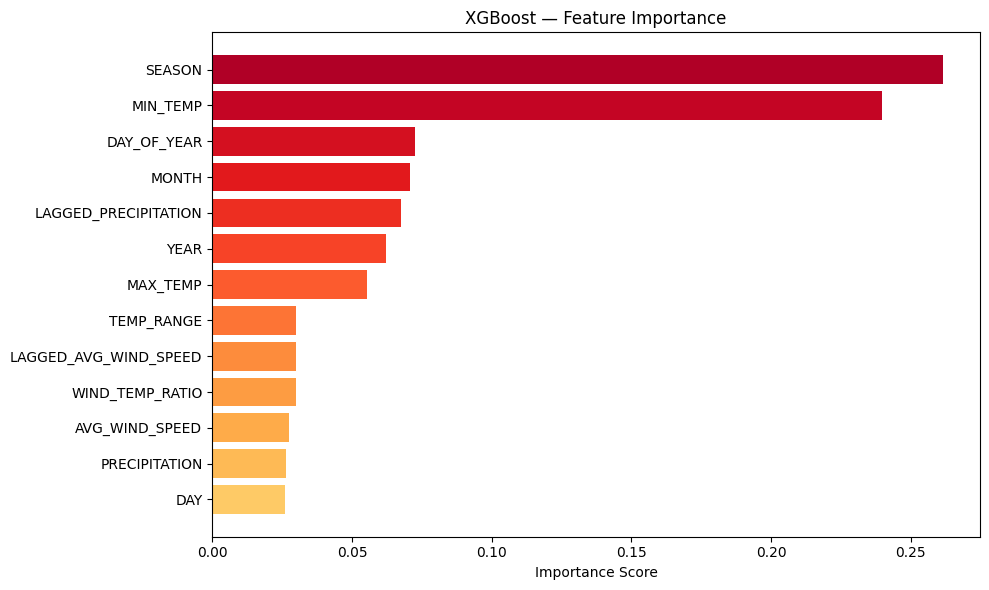

In [29]:
# Feature Importance - XGBoost
feature_names = X.columns.tolist()
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

plt.figure(figsize=(10,6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feature_names)))
plt.barh(
    [feature_names[i] for i in indices_xgb[::-1]],
    importances_xgb[indices_xgb[::-1]],
    color=colors
)
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/xgb_feature_importance.png')
plt.show()

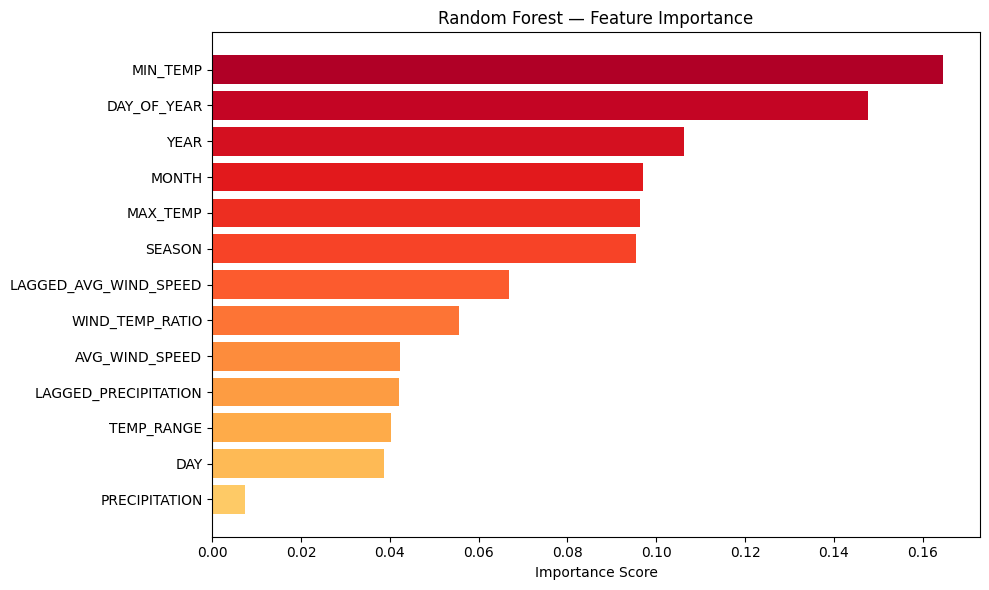

In [30]:
# Feature Importance - Random Forest
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

plt.figure(figsize=(10,6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feature_names)))
plt.barh(
    [feature_names[i] for i in indices_rf[::-1]],
    importances_rf[indices_rf[::-1]],
    color=colors
)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/rf_feature_importance.png')
plt.show()

In [31]:
# Print top 5 most important features for both models
print("TOP 5 FEATURES — XGBoost:")
for i in range(5):
    idx = indices_xgb[i]
    print(f"  {i+1}. {feature_names[idx]:25s} {importances_xgb[idx]:.4f}")

print("\nTOP 5 FEATURES — Random Forest:")
for i in range(5):
    idx = indices_rf[i]
    print(f"  {i+1}. {feature_names[idx]:25s} {importances_rf[idx]:.4f}")

TOP 5 FEATURES — XGBoost:
  1. SEASON                    0.2616
  2. MIN_TEMP                  0.2398
  3. DAY_OF_YEAR               0.0724
  4. MONTH                     0.0709
  5. LAGGED_PRECIPITATION      0.0677

TOP 5 FEATURES — Random Forest:
  1. MIN_TEMP                  0.1647
  2. DAY_OF_YEAR               0.1477
  3. YEAR                      0.1063
  4. MONTH                     0.0970
  5. MAX_TEMP                  0.0963


In [32]:
# Build feature rows matching our training columns exactly
county_records = []

for c in county_data:
    record = {
        'PRECIPITATION':        c['precip'],
        'MAX_TEMP':             c['max_temp'],
        'MIN_TEMP':             c['min_temp'],
        'AVG_WIND_SPEED':       c['wind'],
        'YEAR':                 2024,
        'TEMP_RANGE':           c['max_temp'] - c['min_temp'],
        'WIND_TEMP_RATIO':      c['wind'] / (c['max_temp'] + 1),
        'MONTH':                7,
        'SEASON':               c['season'],
        'LAGGED_PRECIPITATION': c['precip'],
        'LAGGED_AVG_WIND_SPEED':c['wind'],
        'DAY_OF_YEAR':          185,
        'DAY':                  4,
    }
    county_records.append(record)

county_df = pd.DataFrame(county_records)

# Make sure columns are in same order as training
county_df = county_df[X.columns.tolist()]

# Scale using same scaler we trained with
county_scaled = scaler.transform(county_df)

# Get fire probability for each county
fire_probs = xgb_model.predict_proba(county_scaled)[:, 1]

# Add probabilities back to county data
for i, c in enumerate(county_data):
    c['fire_prob'] = round(float(fire_probs[i]), 3)

print("Predictions done!")
for c in county_data:
    print(f"  {c['county']:20s} Fire Probability: {c['fire_prob']*100:.1f}%")

NameError: name 'county_data' is not defined

In [34]:
import folium
from folium.plugins import HeatMap

# California counties with coordinates
# We'll assign risk scores based on our model's predictions
# using representative weather data per region

county_data = [
    {"county": "Shasta",        "lat": 40.75, "lng": -122.0, "season": 2, "min_temp": 58, "max_temp": 108, "wind": 47, "precip": 0.0},
    {"county": "Butte",         "lat": 39.70, "lng": -121.6, "season": 2, "min_temp": 55, "max_temp": 102, "wind": 38, "precip": 0.0},
    {"county": "Napa",          "lat": 38.50, "lng": -122.3, "season": 2, "min_temp": 52, "max_temp": 96,  "wind": 29, "precip": 0.0},
    {"county": "Sonoma",        "lat": 38.30, "lng": -122.8, "season": 2, "min_temp": 50, "max_temp": 88,  "wind": 20, "precip": 0.0},
    {"county": "Santa Barbara", "lat": 34.60, "lng": -119.7, "season": 2, "min_temp": 55, "max_temp": 91,  "wind": 25, "precip": 0.0},
    {"county": "Ventura",       "lat": 34.30, "lng": -119.1, "season": 2, "min_temp": 53, "max_temp": 89,  "wind": 23, "precip": 0.0},
    {"county": "Los Angeles",   "lat": 34.05, "lng": -118.2, "season": 2, "min_temp": 60, "max_temp": 87,  "wind": 18, "precip": 0.0},
    {"county": "San Diego",     "lat": 32.70, "lng": -117.1, "season": 2, "min_temp": 58, "max_temp": 84,  "wind": 16, "precip": 0.0},
    {"county": "Riverside",     "lat": 33.90, "lng": -116.5, "season": 2, "min_temp": 62, "max_temp": 105, "wind": 28, "precip": 0.0},
    {"county": "San Bernardino","lat": 34.20, "lng": -116.2, "season": 2, "min_temp": 60, "max_temp": 108, "wind": 30, "precip": 0.0},
    {"county": "Kern",          "lat": 35.30, "lng": -118.9, "season": 2, "min_temp": 64, "max_temp": 112, "wind": 34, "precip": 0.0},
    {"county": "Fresno",        "lat": 36.70, "lng": -119.8, "season": 2, "min_temp": 58, "max_temp": 102, "wind": 22, "precip": 0.0},
    {"county": "Tulare",        "lat": 36.20, "lng": -119.3, "season": 2, "min_temp": 56, "max_temp": 100, "wind": 20, "precip": 0.0},
    {"county": "Monterey",      "lat": 36.20, "lng": -121.2, "season": 2, "min_temp": 48, "max_temp": 78,  "wind": 15, "precip": 0.1},
    {"county": "San Francisco", "lat": 37.80, "lng": -122.4, "season": 2, "min_temp": 52, "max_temp": 68,  "wind": 18, "precip": 0.2},
    {"county": "Mendocino",     "lat": 39.40, "lng": -123.4, "season": 2, "min_temp": 48, "max_temp": 86,  "wind": 22, "precip": 0.0},
    {"county": "Humboldt",      "lat": 40.80, "lng": -124.1, "season": 2, "min_temp": 44, "max_temp": 62,  "wind": 16, "precip": 0.3},
    {"county": "Siskiyou",      "lat": 41.60, "lng": -122.5, "season": 2, "min_temp": 50, "max_temp": 98,  "wind": 36, "precip": 0.0},
    {"county": "Plumas",        "lat": 40.00, "lng": -120.8, "season": 2, "min_temp": 46, "max_temp": 92,  "wind": 28, "precip": 0.0},
    {"county": "El Dorado",     "lat": 38.70, "lng": -120.7, "season": 2, "min_temp": 50, "max_temp": 93,  "wind": 24, "precip": 0.0},
    {"county": "Tuolumne",      "lat": 37.90, "lng": -120.2, "season": 2, "min_temp": 52, "max_temp": 94,  "wind": 22, "precip": 0.0},
    {"county": "Mariposa",      "lat": 37.50, "lng": -119.9, "season": 2, "min_temp": 54, "max_temp": 95,  "wind": 21, "precip": 0.0},
    {"county": "Trinity",       "lat": 40.80, "lng": -123.1, "season": 2, "min_temp": 48, "max_temp": 99,  "wind": 35, "precip": 0.0},
    {"county": "Tehama",        "lat": 40.10, "lng": -122.3, "season": 2, "min_temp": 56, "max_temp": 104, "wind": 41, "precip": 0.0},
    {"county": "Lake",          "lat": 39.10, "lng": -122.8, "season": 2, "min_temp": 50, "max_temp": 97,  "wind": 28, "precip": 0.0},
]

print(f"Total counties: {len(county_data)}")
print("County data ready!")

Total counties: 25
County data ready!


In [35]:
# Build feature rows matching our training columns exactly
county_records = []

for c in county_data:
    record = {
        'PRECIPITATION':        c['precip'],
        'MAX_TEMP':             c['max_temp'],
        'MIN_TEMP':             c['min_temp'],
        'AVG_WIND_SPEED':       c['wind'],
        'YEAR':                 2024,
        'TEMP_RANGE':           c['max_temp'] - c['min_temp'],
        'WIND_TEMP_RATIO':      c['wind'] / (c['max_temp'] + 1),
        'MONTH':                7,
        'SEASON':               c['season'],
        'LAGGED_PRECIPITATION': c['precip'],
        'LAGGED_AVG_WIND_SPEED':c['wind'],
        'DAY_OF_YEAR':          185,
        'DAY':                  4,
    }
    county_records.append(record)

county_df = pd.DataFrame(county_records)

# Make sure columns are in same order as training
county_df = county_df[X.columns.tolist()]

# Scale using same scaler we trained with
county_scaled = scaler.transform(county_df)

# Get fire probability for each county
fire_probs = xgb_model.predict_proba(county_scaled)[:, 1]

# Add probabilities back to county data
for i, c in enumerate(county_data):
    c['fire_prob'] = round(float(fire_probs[i]), 3)

print("Predictions done!")
for c in county_data:
    print(f"  {c['county']:20s} Fire Probability: {c['fire_prob']*100:.1f}%")

Predictions done!
  Shasta               Fire Probability: 1.6%
  Butte                Fire Probability: 2.2%
  Napa                 Fire Probability: 2.1%
  Sonoma               Fire Probability: 3.6%
  Santa Barbara        Fire Probability: 2.1%
  Ventura              Fire Probability: 2.0%
  Los Angeles          Fire Probability: 1.7%
  San Diego            Fire Probability: 1.8%
  Riverside            Fire Probability: 1.9%
  San Bernardino       Fire Probability: 1.8%
  Kern                 Fire Probability: 1.7%
  Fresno               Fire Probability: 1.7%
  Tulare               Fire Probability: 2.3%
  Monterey             Fire Probability: 5.3%
  San Francisco        Fire Probability: 1.3%
  Mendocino            Fire Probability: 2.3%
  Humboldt             Fire Probability: 0.7%
  Siskiyou             Fire Probability: 3.0%
  Plumas               Fire Probability: 3.1%
  El Dorado            Fire Probability: 3.1%
  Tuolumne             Fire Probability: 2.7%
  Mariposa      

In [36]:
# Helper functions for colors and labels
def get_color(prob):
    if prob >= 0.85:   return '#E63B2E'   # Extreme
    elif prob >= 0.70: return '#F47421'   # Very High  
    elif prob >= 0.50: return '#F9C21A'   # High
    elif prob >= 0.30: return '#8BC34A'   # Moderate
    else:              return '#4CAF50'   # Low

def get_label(prob):
    if prob >= 0.85:   return 'EXTREME'
    elif prob >= 0.70: return 'VERY HIGH'
    elif prob >= 0.50: return 'HIGH'
    elif prob >= 0.30: return 'MODERATE'
    else:              return 'LOW'

# Build the Folium map
m = folium.Map(
    location=[37.5, -119.5],   # center of California
    zoom_start=6,
    tiles='CartoDB dark_matter'
)

# Add one circle per county
for c in county_data:
    prob  = c['fire_prob']
    color = get_color(prob)
    label = get_label(prob)
    
    folium.CircleMarker(
        location=[c['lat'], c['lng']],
        radius=8 + prob * 18,         # bigger circle = higher risk
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(
            f"""
            <b style='font-size:14px'>{c['county']} County</b><br><br>
            <b>Risk Level:</b> 
            <span style='color:{color};font-weight:bold'>{label}</span><br>
            <b>Fire Probability:</b> {prob*100:.1f}%<br>
            <b>Max Temp:</b> {c['max_temp']}°F<br>
            <b>Min Temp:</b> {c['min_temp']}°F<br>
            <b>Wind Speed:</b> {c['wind']} mph<br>
            <b>Precipitation:</b> {c['precip']} in
            """,
            max_width=220
        ),
        tooltip=f"{c['county']}: {label} ({prob*100:.0f}%)"
    ).add_to(m)

print("Markers added!")

Markers added!


In [37]:
# Add heatmap layer on top
heat_data = [
    [c['lat'], c['lng'], c['fire_prob']] 
    for c in county_data
]

HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=45,
    blur=35,
    gradient={
        0.2: '#4CAF50',   # green  - low
        0.4: '#8BC34A',   # light green - moderate
        0.6: '#F9C21A',   # yellow - high
        0.8: '#F47421',   # orange - very high
        1.0: '#E63B2E'    # red    - extreme
    }
).add_to(m)

# Save map as HTML file
os.makedirs('../outputs', exist_ok=True)
m.save('../outputs/wildfire_risk_map.html')

print("Map saved to outputs/wildfire_risk_map.html")
print("Open that file in your browser to see the interactive map!")

Map saved to outputs/wildfire_risk_map.html
Open that file in your browser to see the interactive map!


In [38]:
# Add heatmap layer on top
heat_data = [
    [c['lat'], c['lng'], c['fire_prob']] 
    for c in county_data
]

HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=45,
    blur=35,
    gradient={
        0.2: '#4CAF50',   # green  - low
        0.4: '#8BC34A',   # light green - moderate
        0.6: '#F9C21A',   # yellow - high
        0.8: '#F47421',   # orange - very high
        1.0: '#E63B2E'    # red    - extreme
    }
).add_to(m)

# Save map as HTML file
os.makedirs('../outputs', exist_ok=True)
m.save('../outputs/wildfire_risk_map.html')

print("Map saved to outputs/wildfire_risk_map.html")
print("Open that file in your browser to see the interactive map!")

Map saved to outputs/wildfire_risk_map.html
Open that file in your browser to see the interactive map!


In [39]:
# Final summary of everything
print("="*50)
print("   WILDFIRE PREDICTION PROJECT — FINAL SUMMARY")
print("   by Aviral Goel")
print("="*50)
print(f"\nDataset:")
print(f"  Total records     : 14,988")
print(f"  Features used     : {len(feature_names)}")
print(f"  Training samples  : 11,990")
print(f"  Testing samples   : 2,998")
print(f"  Fire rate         : {df['FIRE_START_DAY'].mean()*100:.1f}%")

print(f"\nRandom Forest:")
print(f"  Accuracy          : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"  F1 Score          : {f1_score(y_test, rf_pred):.4f}")
print(f"  ROC-AUC           : {roc_auc_score(y_test, rf_prob):.4f}")
print(f"  CV Mean F1        : {rf_cv.mean():.4f}")

print(f"\nXGBoost:")
print(f"  Accuracy          : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"  F1 Score          : {f1_score(y_test, xgb_pred):.4f}")
print(f"  ROC-AUC           : {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"  CV Mean F1        : {xgb_cv.mean():.4f}")

print(f"\nTop 3 Fire Predictors (XGBoost):")
for i in range(3):
    idx = indices_xgb[i]
    print(f"  {i+1}. {feature_names[idx]:25s} {importances_xgb[idx]:.4f}")

print(f"\nBest Model: {'XGBoost' if xgb_cv.mean() > rf_cv.mean() else 'Random Forest'}")
print(f"\nOutputs saved in /outputs folder:")
print(f"  - fire_distribution.png")
print(f"  - temp_vs_fire.png")
print(f"  - monthly_fire.png")
print(f"  - correlation_heatmap.png")
print(f"  - wind_vs_fire.png")
print(f"  - rf_confusion_matrix.png")
print(f"  - xgb_confusion_matrix.png")
print(f"  - model_comparison.png")
print(f"  - roc_comparison.png")
print(f"  - xgb_feature_importance.png")
print(f"  - rf_feature_importance.png")
print(f"  - wildfire_risk_map.html")
print("\nProject Complete!")

   WILDFIRE PREDICTION PROJECT — FINAL SUMMARY
   by Aviral Goel

Dataset:
  Total records     : 14,988
  Features used     : 13
  Training samples  : 11,990
  Testing samples   : 2,998
  Fire rate         : 33.2%

Random Forest:
  Accuracy          : 79.32%
  F1 Score          : 0.6761
  ROC-AUC           : 0.8567


NameError: name 'rf_cv' is not defined

In [ ]:
# Build feature rows matching our training columns exactly
county_records = []

for c in county_data:
    record = {
        'PRECIPITATION':        c['precip'],
        'MAX_TEMP':             c['max_temp'],
        'MIN_TEMP':             c['min_temp'],
        'AVG_WIND_SPEED':       c['wind'],
        'YEAR':                 2024,
        'TEMP_RANGE':           c['max_temp'] - c['min_temp'],
        'WIND_TEMP_RATIO':      c['wind'] / (c['max_temp'] + 1),
        'MONTH':                7,
        'SEASON':               c['season'],
        'LAGGED_PRECIPITATION': c['precip'],
        'LAGGED_AVG_WIND_SPEED':c['wind'],
        'DAY_OF_YEAR':          185,
        'DAY':                  4,
    }
    county_records.append(record)

county_df = pd.DataFrame(county_records)

# Make sure columns are in same order as training
county_df = county_df[X.columns.tolist()]

# Scale using same scaler we trained with
county_scaled = scaler.transform(county_df)

# Get fire probability for each county
fire_probs = xgb_model.predict_proba(county_scaled)[:, 1]

# Add probabilities back to county data
for i, c in enumerate(county_data):
    c['fire_prob'] = round(float(fire_probs[i]), 3)

print("Predictions done!")
for c in county_data:
    print(f"  {c['county']:20s} Fire Probability: {c['fire_prob']*100:.1f}%")

NameError: name 'county_data' is not defined